In [1]:
import numpy as np
import pandas as pd
import rasterio

from tqdm import tqdm
from scipy.ndimage import uniform_filter, sobel
from config import config
from xgboost import XGBClassifier
from joblib import Parallel, delayed
from utils import (
    build_metadata, plot_class_distribution, split_metadata, 
    compute_band_stats, print_split_summary, refine_mask_small_components,
    encode_labels, count_by_class, evaluate_split, sample_training_pixels
)


In [2]:
def normalized_diff(a, b, eps=1e-6):
    return (a - b) / (a + b + eps)


def preprocess_img(img_path, mask_path):
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
        if src.count >= 2:
            confidence = src.read(2).astype(np.float32)
        else:
            confidence = np.full(mask.shape, 100.0, dtype=np.float32)
    
    refined_mask, refined_confidence, _ = refine_mask_small_components(
        mask,
        confidence=confidence,
        return_details=True,
        **config.REFINE_KWARGS,
    )
    img = np.clip(img, 0, 10000) / 10000.0
    confidence = np.clip(refined_confidence / 100.0, config.CONFIDENCE_FLOOR, 1.0)
    return img, refined_mask, confidence


def local_mean_std(img, size=5):
    mean = uniform_filter(img, size=size)
    mean_sq = uniform_filter(img * img, size=size)
    var = np.maximum(mean_sq - mean * mean, 0.0)
    std = np.sqrt(var)
    return mean, std

def local_var(img, size=5):
    mean = uniform_filter(img, size=size)
    mean_sq = uniform_filter(img * img, size=size)
    var = np.maximum(mean_sq - mean * mean, 0.0)
    return var

def edge_magnitude(img):
    gx = sobel(img, axis=0)
    gy = sobel(img, axis=1)
    return np.hypot(gx, gy)

def extract_features(img):
    b_raw = img.astype(np.float32)

    blue = b_raw[1]
    green = b_raw[2]
    red = b_raw[3]
    nir = b_raw[7]
    swir1 = b_raw[10]
    swir2 = b_raw[11]

    b = (b_raw - config.BAND_MEANS[:, None, None]) / config.BAND_STDS[:, None, None]
    bands_std = np.std(b_raw, axis=0)
    brightness = np.mean(b_raw[[1, 2, 3]], axis=0)

    ndvi = normalized_diff(nir, red)
    ndwi = normalized_diff(green, nir)
    mndwi = normalized_diff(green, swir1)
    ndbi = normalized_diff(swir1, nir)
    bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-6)
    awei_sh = blue + 2.5 * green - 1.5 * (nir + swir1) - 0.25 * swir2
    awei_nsh = 4.0 * (green - swir1) - (0.25 * nir + 2.75 * swir2)

    red_mean_3, red_std_3 = local_mean_std(red, size=3)
    nir_mean_3, nir_std_3 = local_mean_std(nir, size=3)
    swir1_mean_3, swir1_std_3 = local_mean_std(swir1, size=3)
    swir2_mean_3, swir2_std_3 = local_mean_std(swir2, size=3)
    ndwi_mean_3, ndwi_std_3 = local_mean_std(ndwi, size=3)
    mndwi_mean_3, mndwi_std_3 = local_mean_std(mndwi, size=3)

    red_mean_5, red_std_5 = local_mean_std(red, size=5)
    nir_mean_5, nir_std_5 = local_mean_std(nir, size=5)
    swir1_mean_5, swir1_std_5 = local_mean_std(swir1, size=5)
    swir2_mean_5, swir2_std_5 = local_mean_std(swir2, size=5)
    ndwi_mean_5, ndwi_std_5 = local_mean_std(ndwi, size=5)
    mndwi_mean_5, mndwi_std_5 = local_mean_std(mndwi, size=5)

    nir_var_5 = local_var(nir, size=5)
    swir1_var_5 = local_var(swir1, size=5)

    nir_edge = edge_magnitude(nir)
    swir1_edge = edge_magnitude(swir1)
    ndwi_edge = edge_magnitude(ndwi)
    mndwi_edge = edge_magnitude(mndwi)

    features = np.concatenate(
        [
            b,
            ndvi[np.newaxis, ...],
            ndwi[np.newaxis, ...],
            mndwi[np.newaxis, ...],
            ndbi[np.newaxis, ...],
            bsi[np.newaxis, ...],
            awei_sh[np.newaxis, ...],
            awei_nsh[np.newaxis, ...],
            brightness[np.newaxis, ...],

            bands_std[np.newaxis, ...],
            red_mean_3[np.newaxis, ...],
            red_std_3[np.newaxis, ...],
            nir_mean_3[np.newaxis, ...],
            nir_std_3[np.newaxis, ...],
            swir1_mean_3[np.newaxis, ...],
            swir1_std_3[np.newaxis, ...],
            swir2_mean_3[np.newaxis, ...],
            swir2_std_3[np.newaxis, ...],
            ndwi_mean_3[np.newaxis, ...],
            ndwi_std_3[np.newaxis, ...],
            mndwi_mean_3[np.newaxis, ...],
            mndwi_std_3[np.newaxis, ...],

            red_mean_5[np.newaxis, ...],
            red_std_5[np.newaxis, ...],
            nir_mean_5[np.newaxis, ...],
            nir_std_5[np.newaxis, ...],
            swir1_mean_5[np.newaxis, ...],
            swir1_std_5[np.newaxis, ...],
            swir2_mean_5[np.newaxis, ...],
            swir2_std_5[np.newaxis, ...],
            ndwi_mean_5[np.newaxis, ...],
            ndwi_std_5[np.newaxis, ...],
            mndwi_mean_5[np.newaxis, ...],
            mndwi_std_5[np.newaxis, ...],

            nir_var_5[np.newaxis, ...],
            swir1_var_5[np.newaxis, ...],

            nir_edge[np.newaxis, ...],
            swir1_edge[np.newaxis, ...],
            ndwi_edge[np.newaxis, ...],
            mndwi_edge[np.newaxis, ...],
        ],
        axis=0,
    )

    feature_names = [f'B{i + 1}' for i in range(b.shape[0])] + [
        'ndvi',
        'ndwi',
        'mndwi',
        'ndbi',
        'bsi',
        'awei_sh',
        'awei_nsh',
        'brightness',
        
        'bands_std',
        'red_mean_3',
        'red_std_3',
        'nir_mean_3',
        'nir_std_3',
        'swir1_mean_3',
        'swir1_std_3',
        'swir2_mean_3',
        'swir2_std_3',
        'ndwi_mean_3',
        'ndwi_std_3',
        'mndwi_mean_3',
        'mndwi_std_3',

        'red_mean_5',
        'red_std_5',
        'nir_mean_5',
        'nir_std_5',
        'swir1_mean_5',
        'swir1_std_5',
        'swir2_mean_5',
        'swir2_std_5',
        'ndwi_mean_5',
        'ndwi_std_5',
        'mndwi_mean_5',
        'mndwi_std_5',

        'nir_var_5',
        'swir1_var_5',

        'nir_edge',
        'swir1_edge',
        'ndwi_edge',
        'mndwi_edge',
    ]

    return features, feature_names


def process_pair(img_path, mask_path):
    img, mask, confidence = preprocess_img(img_path, mask_path)
    features, feature_names = extract_features(img)

    valid = (mask != 0) & (confidence * 100.0 >= config.MIN_CONFIDENCE) & (~np.all(img[:12] <= 1e-8, axis=0))
    X = features[:, valid].T.astype(np.float32)
    y = mask[valid].reshape(-1).astype(np.uint8)
    pixel_weight = confidence[valid].reshape(-1).astype(np.float32)

    return X, y, pixel_weight, feature_names


def build_dataset(split_df, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'])
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    weight_parts = []
    feature_names = None

    for X, y, pixel_weight, names in results:
        X_parts.append(X)
        y_parts.append(y)
        weight_parts.append(pixel_weight)
        if feature_names is None:
            feature_names = names

    X_all = np.concatenate(X_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    weight_all = np.concatenate(weight_parts, axis=0)
    return X_all, y_all, weight_all, feature_names

In [3]:
meta = build_metadata(config.DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)
band_means, band_stds = compute_band_stats(train_meta['img_path'])
config.set_band_stats_once(band_means, band_stds)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)
print('Band means:', np.round(config.BAND_MEANS, 6).tolist())
print('Band stds :', np.round(config.BAND_STDS, 6).tolist())

Computing band stats: 100%|██████████| 210/210 [00:01<00:00, 121.97it/s]

[train] images: 210
  Unknown  pixels=    5,793 images= 74
  Greenery pixels=9,147,871 images=198
  Sand     pixels=3,666,708 images=174
  Water    pixels=  368,670 images= 33
  Cement   pixels=  573,518 images=164
  strata: {'cement_only': 135, 'base': 42, 'water_and_cement': 29, 'water_only': 4}
[val] images: 45
  Unknown  pixels=      110 images=  7
  Greenery pixels=2,049,097 images= 42
  Sand     pixels=  844,585 images= 38
  Water    pixels=   24,787 images=  7
  Cement   pixels=   30,541 images= 35
  strata: {'cement_only': 29, 'base': 9, 'water_and_cement': 6, 'water_only': 1}
[test] images: 45
  Unknown  pixels=    3,921 images= 19
  Greenery pixels=1,748,660 images= 43
  Sand     pixels=  905,788 images= 38
  Water    pixels=   30,064 images=  8
  Cement   pixels=  260,687 images= 35
  strata: {'cement_only': 28, 'base': 9, 'water_and_cement': 7, 'water_only': 1}
Band means: [0.055424999445676804, 0.07226800173521042, 0.11215999722480774, 0.14573900401592255, 0.18726600706577

In [4]:
print(train_meta.head())

  sample_id               img_path                mask_path  total_pixels  \
0        62   data/imgs/img_62.tif   data/masks/mask_62.tif         65536   
1       235  data/imgs/img_235.tif  data/masks/mask_235.tif         65536   
2       131  data/imgs/img_131.tif  data/masks/mask_131.tif         65536   
3       236  data/imgs/img_236.tif  data/masks/mask_236.tif         65536   
4       195  data/imgs/img_195.tif  data/masks/mask_195.tif         65536   

   has_water  has_cement  has_sand  count_0  count_1  count_2  count_3  \
0          0           0         1        0    65532        4        0   
1          1           1         1        6     9942    55555        6   
2          0           1         1        0    53280    10670        0   
3          0           1         1       99    40699    24689        0   
4          0           1         1        0    64984      115        0   

   count_4           stratum  
0        0              base  
1       27  water_and_cement  

Building dataset: 100%|██████████| 45/45 [00:00<00:00, 118.83it/s]


Train full: (13728960, 51) {'Greenery': 9150985, 'Sand': 3634559, 'Water': 368708, 'Cement': 574708}
Val      : (2949120, 51) {'Greenery': 2049206, 'Sand': 844586, 'Water': 24787, 'Cement': 30541}
Test     : (2947636, 51) {'Greenery': 1749810, 'Sand': 906185, 'Water': 30774, 'Cement': 260867}
Train confidence weight range: 0.33000001311302185 1.0
Greenery available=9,150,985 sampled=  400,000
Sand     available=3,634,559 sampled=  400,000
Water    available=  368,708 sampled=  368,708
Cement   available=  574,708 sampled=  574,708
Greenery available=2,049,206 sampled=  100,000
Sand     available=  844,586 sampled=  100,000
Water    available=   24,787 sampled=   24,787
Cement   available=   30,541 sampled=   30,541
Greenery available=1,749,810 sampled=  100,000
Sand     available=  906,185 sampled=  100,000
Water    available=   30,774 sampled=   30,774
Cement   available=  260,867 sampled=  260,867
Train sampled: (1743416, 51) {'Greenery': 400000, 'Sand': 400000, 'Water': 368708, 'Cem

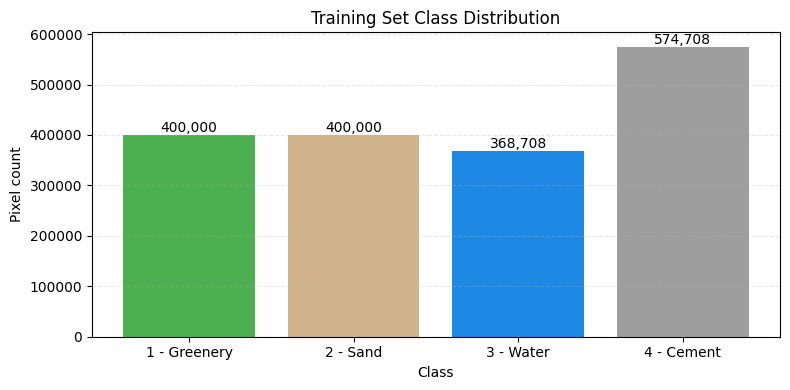

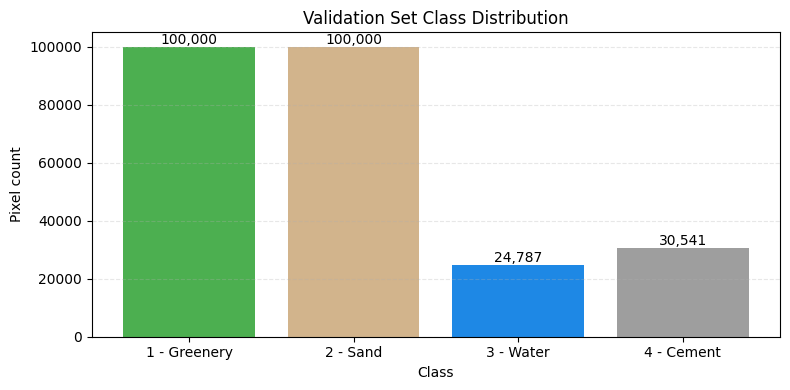

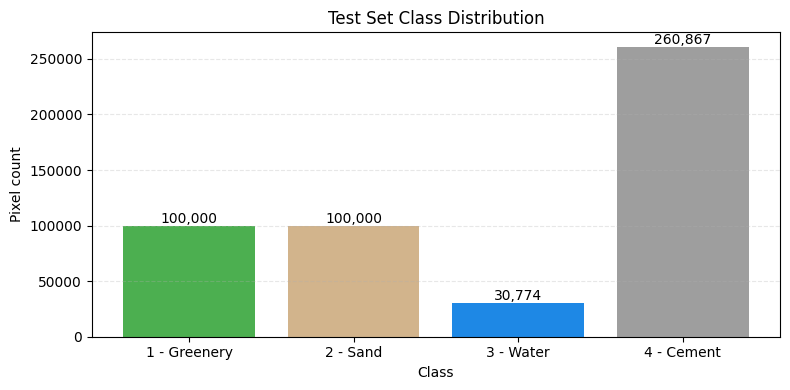

In [5]:
X_train_full, y_train_full, conf_train_full, feature_names = build_dataset(train_meta)
X_val, y_val, _, _ = build_dataset(val_meta)
X_test, y_test, _, _ = build_dataset(test_meta)

print('Train full:', X_train_full.shape, count_by_class(y_train_full))
print('Val      :', X_val.shape, count_by_class(y_val))
print('Test     :', X_test.shape, count_by_class(y_test))
print('Train confidence weight range:', float(conf_train_full.min()), float(conf_train_full.max()))

X_train, y_train, conf_train = sample_training_pixels(X_train_full, y_train_full, conf_train_full)
X_val, y_val, _ = sample_training_pixels(X_val, y_val, np.ones_like(y_val), caps=config.VAL_TEST_CAPS)
X_test, y_test, _ = sample_training_pixels(X_test, y_test, np.ones_like(y_test), caps=config.VAL_TEST_CAPS)
print('Train sampled:', X_train.shape, count_by_class(y_train))
print('Val sampled  :', X_val.shape, count_by_class(y_val))
print('Test sampled :', X_test.shape, count_by_class(y_test))
plot_class_distribution(y_train, 'Training Set Class Distribution')
plot_class_distribution(y_val, 'Validation Set Class Distribution')
plot_class_distribution(y_test, 'Test Set Class Distribution')

In [6]:
y_train_enc = encode_labels(y_train)
sample_weight = conf_train.copy()
sample_weight[y_train == 3] *= config.WATER_WEIGHT_MULTIPLIER
sample_weight[y_train == 4] *= config.CEMENT_WEIGHT_MULTIPLIER
print('Weighted classes:', {
    'Water': config.WATER_WEIGHT_MULTIPLIER,
    'Cement': config.CEMENT_WEIGHT_MULTIPLIER,
})

model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=3,
    reg_alpha=0.05,
    reg_lambda=1.5,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=config.RANDOM_STATE,
)

model.fit(X_train, y_train_enc, sample_weight=sample_weight)


Weighted classes: {'Water': 3.0, 'Cement': 2.0}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

===== Train =====
              precision    recall  f1-score   support

           1     0.8736    0.8993    0.8862    400000
           2     0.9321    0.8675    0.8986    400000
           3     0.9901    0.9997    0.9949    368708
           4     0.9421    0.9624    0.9522    574708

    accuracy                         0.9340   1743416
   macro avg     0.9345    0.9322    0.9330   1743416
weighted avg     0.9342    0.9340    0.9338   1743416

Confusion Matrix:
 [[359708  19889   2658  17745]
 [ 36224 347012    553  16211]
 [    87      4 368605     12]
 [ 15752   5393    477 553086]]
mIoU: 0.8775358976204266
Per-class IoU: {'Greenery': 0.7957032537500304, 'Sand': 0.8159497373532164, 'Water': 0.9898199765840664, 'Cement': 0.908670622794393}


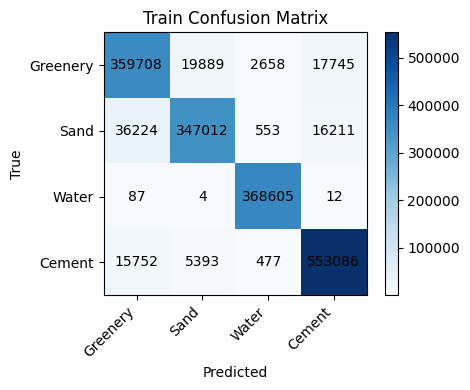

(array([[359708,  19889,   2658,  17745],
        [ 36224, 347012,    553,  16211],
        [    87,      4, 368605,     12],
        [ 15752,   5393,    477, 553086]]),
 0.8775358976204266,
 array([0.79570325, 0.81594974, 0.98981998, 0.90867062]))

In [7]:
evaluate_split("Train", model, X_train, y_train)

===== Validation =====
              precision    recall  f1-score   support

           1     0.8102    0.9038    0.8544    100000
           2     0.9082    0.8244    0.8643    100000
           3     0.9168    0.9764    0.9457     24787
           4     0.7588    0.6608    0.7064     30541

    accuracy                         0.8507    255328
   macro avg     0.8485    0.8414    0.8427    255328
weighted avg     0.8528    0.8507    0.8494    255328

Confusion Matrix:
 [[90378  4134  1852  3636]
 [14655 82442   200  2703]
 [  394   112 24203    78]
 [ 6123  4091   144 20183]]
mIoU: 0.7374803152271145
Per-class IoU: {'Greenery': 0.745865381441257, 'Sand': 0.7609773207676048, 'Water': 0.89697216766112, 'Cement': 0.5461063910384761}


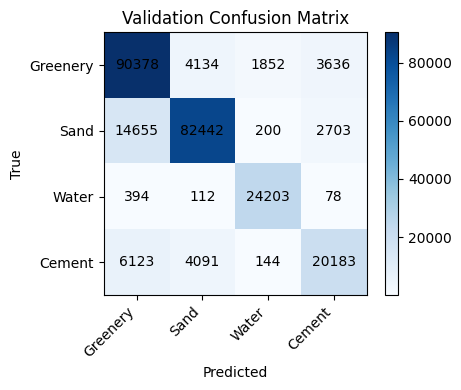

(array([[90378,  4134,  1852,  3636],
        [14655, 82442,   200,  2703],
        [  394,   112, 24203,    78],
        [ 6123,  4091,   144, 20183]]),
 0.7374803152271145,
 array([0.74586538, 0.76097732, 0.89697217, 0.54610639]))

In [8]:
evaluate_split('Validation', model, X_val, y_val)

===== Test =====
              precision    recall  f1-score   support

           1     0.7117    0.7659    0.7378    100000
           2     0.7474    0.7317    0.7395    100000
           3     0.8075    0.7425    0.7736     30774
           4     0.9342    0.9233    0.9287    260867

    accuracy                         0.8410    491641
   macro avg     0.8002    0.7909    0.7949    491641
weighted avg     0.8430    0.8410    0.8417    491641

Confusion Matrix:
 [[ 76592  10965   3980   8463]
 [ 18338  73173    559   7930]
 [  6197   1163  22850    564]
 [  6493  12599    909 240866]]
mIoU: 0.6672543795044025
Per-class IoU: {'Greenery': 0.584546814421345, 'Sand': 0.5866652769648913, 'Water': 0.6308320909944233, 'Cement': 0.86697333563695}


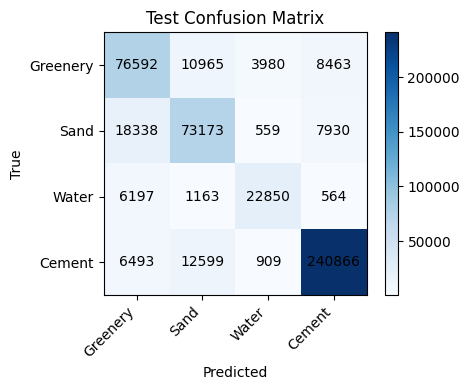

(array([[ 76592,  10965,   3980,   8463],
        [ 18338,  73173,    559,   7930],
        [  6197,   1163,  22850,    564],
        [  6493,  12599,    909, 240866]]),
 0.6672543795044025,
 array([0.58454681, 0.58666528, 0.63083209, 0.86697334]))

In [9]:
evaluate_split('Test', model, X_test, y_test)

In [10]:
importance_df = pd.DataFrame(
    {
        'feature': feature_names,
        'importance': model.feature_importances_,
    }
).sort_values('importance', ascending=False)

display(importance_df.head(20))

,feature,importance
18,awei_nsh,0.464339
17,awei_sh,0.100775
34,red_std_5,0.074435
41,ndwi_mean_5,0.050872
37,swir1_mean_5,0.047800
25,swir1_mean_3,0.028422
22,red_std_3,0.026037
12,ndvi,0.018970
29,ndwi_mean_3,0.018635
44,mndwi_std_5,0.016188
